# Evaluating Classification Models

## Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

%matplotlib inline

## Load the Breast Cancer dataset

In [2]:
data = load_breast_cancer()
X: np.ndarray = data.data
y: np.ndarray = data.target
labels: np.ndarray = data.target_names
feature_names: np.ndarray = data.feature_names

## Print the description of the Breast Cancer dataset

In [3]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

<p>In summary, each observation in the dataset consists of a variety attributes measured from a sample of cells from a suspicious mass taken from a patient. The goal is to predict whether a mass is malignant (positive case) or benign (negative case).</p>

In [4]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

## Standardize the data

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Add some noise

<p>Next, add some noise to simulate random measurement error, then view the first few rows of the original and noisy features for comparison.</p>

In [6]:
np.random.seed(42)
noise_factor = 0.5
X_noisy = X_scaled + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

df = pd.DataFrame(X_scaled, columns=feature_names)
df_noisy = pd.DataFrame(X_noisy, columns=feature_names)

In [7]:
print("Original Data (First 5 rows): ")
df.head()

Original Data (First 5 rows): 


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [8]:
print("Noisy Data (First 5 rows): ")
df_noisy.head()

Noisy Data (First 5 rows): 


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.345421,-2.142467,1.593778,1.745890,1.451390,3.166446,3.442480,2.916193,1.982778,2.527027,...,2.619514,-1.472182,2.337365,1.288863,1.035495,2.672126,1.534030,2.483925,2.450303,1.791168
1,1.528967,0.572507,1.679206,1.379853,-0.415690,-1.097493,0.080586,-0.431691,-0.662701,-0.770222,...,1.967969,-0.561744,1.196665,2.196327,0.139888,0.035196,-0.566358,0.932478,-0.078258,0.768963
2,1.340301,0.363357,1.013336,0.960780,1.348473,1.731046,1.327473,2.538997,1.120503,-0.720568,...,1.402034,0.154582,2.086422,1.197149,0.123161,0.832054,1.312675,2.119376,0.887375,0.458025
3,-0.720371,0.738055,-0.943714,-0.928295,3.087499,2.671152,2.063957,1.582235,2.869940,4.793626,...,-1.240850,0.120727,-0.219824,0.681600,3.298094,4.044171,1.972232,1.591447,6.617453,5.310977
4,2.145813,-1.606510,2.477970,1.125304,0.573800,1.634568,0.875743,1.145344,0.040265,-0.814188,...,1.412305,-0.813199,0.534798,1.313041,0.350498,0.077517,-0.005297,0.069031,-0.607382,-0.248607


## Visualizing the noise content

<p>You can get a good idea of how much noise there is in the features by comparing values in the previous tables. You can also visualize the differences in several ways. Let's begin by plotting the histograms of one of the features with and without noise for comparison.</p>

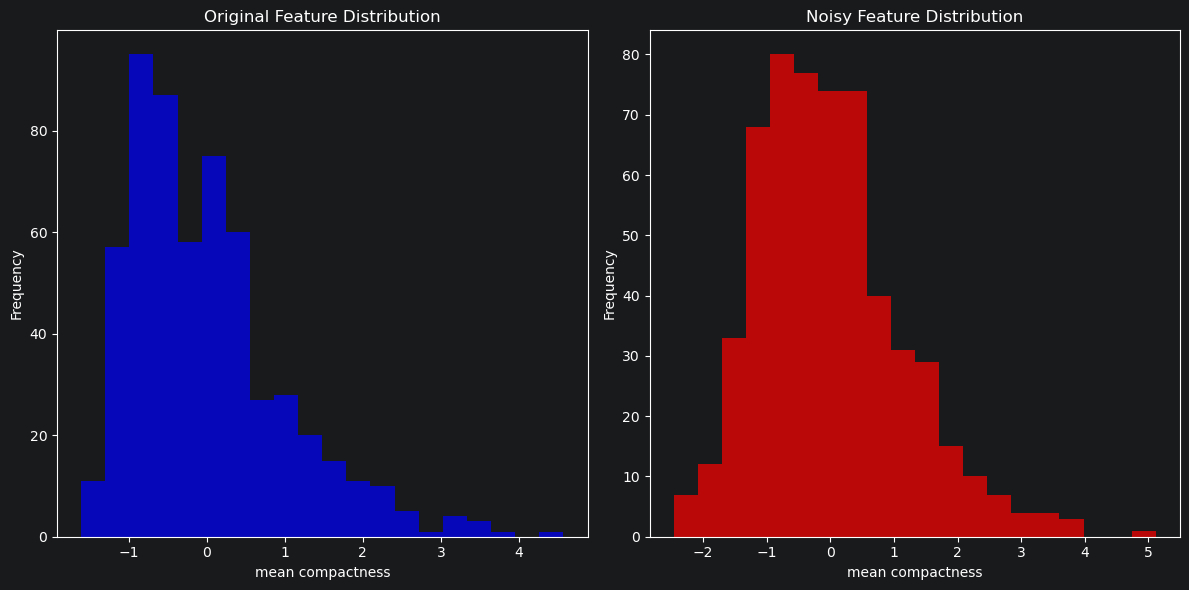

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df.loc[:, feature_names[5]], bins=20, alpha=0.7, color="blue", label="Original")
plt.title("Original Feature Distribution")
plt.xlabel(feature_names[5])
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df_noisy.loc[:, feature_names[5]], bins=20, alpha=0.7, color="red", label="Noisy")
plt.title("Noisy Feature Distribution")
plt.xlabel(feature_names[5])
plt.ylabel("Frequency")

plt.tight_layout()

<p>The noise-free histogram is skewed to the left and appears to a log-normal distribution, while the noisy histogram is less skewed, tending toward a normal distribution.</p>
<p>You can also plot the two features together to get a sense of their differences.</p>

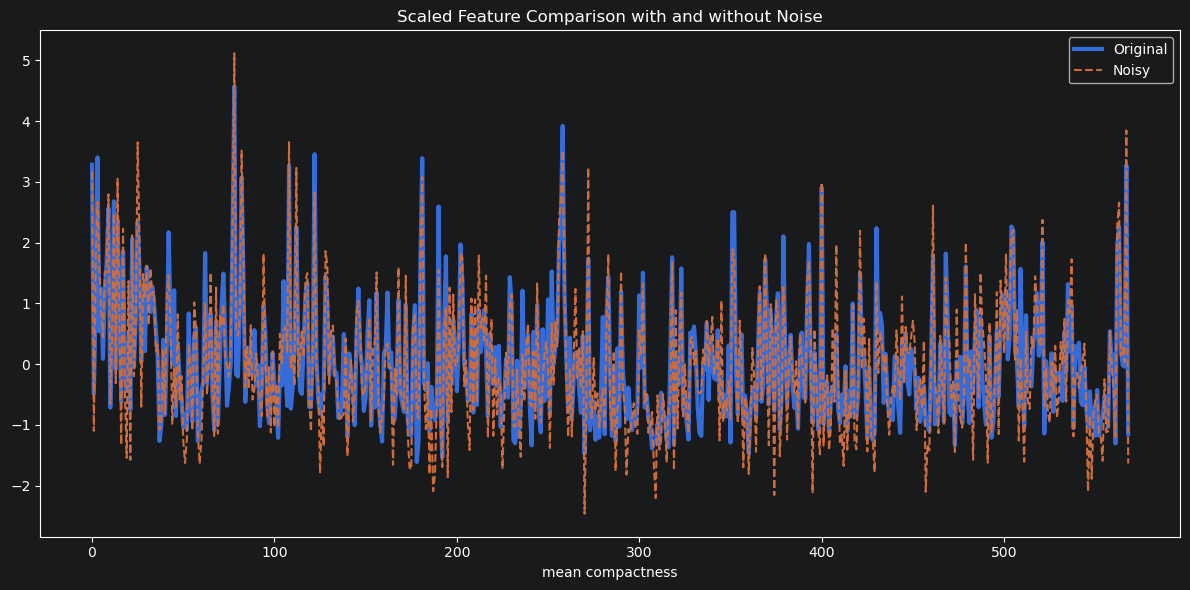

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df.loc[:, feature_names[5]], label="Original", lw=3)
plt.plot(df_noisy.loc[:, feature_names[5]], "--", label="Noisy")
plt.title("Scaled Feature Comparison with and without Noise")
plt.xlabel(feature_names[5])
plt.legend()
plt.tight_layout()

<p>Finally, you can compare the two features using a scatterplot. This gives you an excellent idea of how well the two features are correlated.</p>

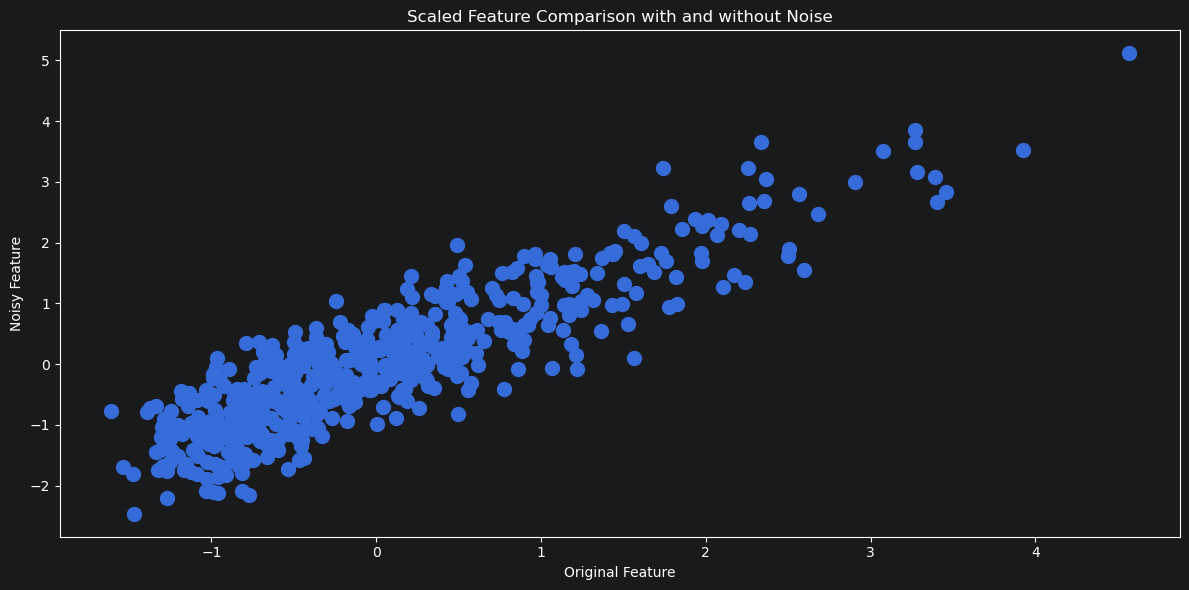

In [11]:
plt.figure(figsize=(12, 6))
plt.scatter(df.loc[:, feature_names[5]], df_noisy.loc[:, feature_names[5]], lw=5)
plt.title("Scaled Feature Comparison with and without Noise")
plt.xlabel("Original Feature")
plt.ylabel("Noisy Feature")
plt.tight_layout()

## Split the data and fit the KNN and SVM models to the noisy training data

In [12]:
split_data = train_test_split(X_noisy, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = split_data

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

svm = SVC(kernel="linear", C=1, random_state=42)
svm.fit(X_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Evaluate the models

<p>Predict on the test set and print the accuracy scores and classification reports for both models.</p>

In [13]:
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)

In [14]:
print(f"KNN Testing Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"SVM Testing Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}", end="\n\n")

print(f"KNN Testing Data Classification Report:")
print(classification_report(y_test, y_pred_knn))
print(f"SVM Testing Data Classification Report:")
print(classification_report(y_test, y_pred_svm))

KNN Testing Accuracy: 0.936
SVM Testing Accuracy: 0.971

KNN Testing Data Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        63
           1       0.94      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

SVM Testing Data Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        63
           1       0.98      0.97      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



### Plot the confusion matrices

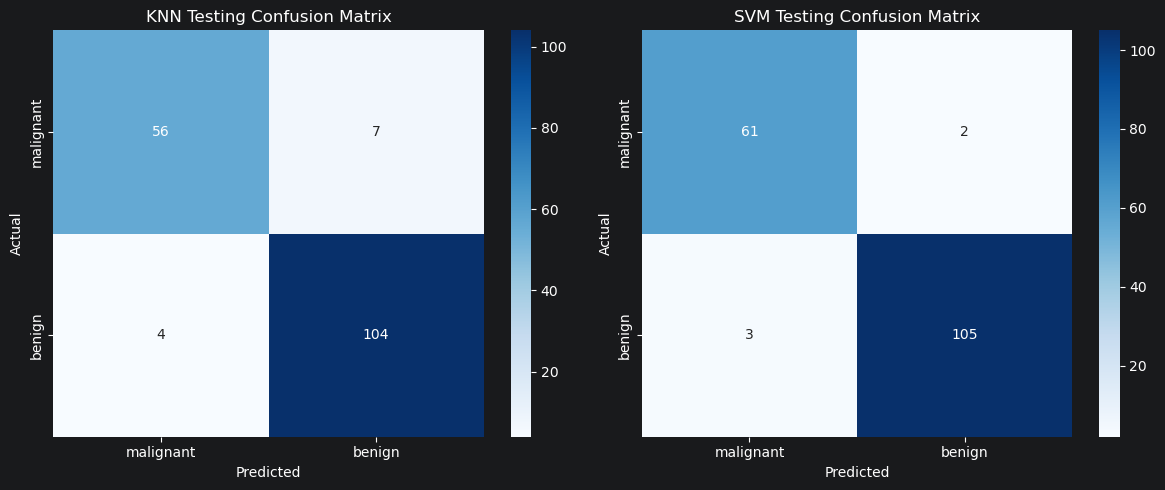

In [15]:
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_matrix_knn, annot=True, cmap="Blues", fmt="d", ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title("KNN Testing Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_svm, annot=True, cmap="Blues", fmt="d", ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title("SVM Testing Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

<p>It would indeed be vary unpleasant to be told you have cancer, when in fact you don't. But the consequences of being told you don't have cancer when you actually do are life threatening. State this worse-case scenario in terms of true/false positive/negative diagnoses, and identify their counts from the confusion matrices.</p>
<p>By convention, a positive test for malignancy means a diagnosis of a mass being malignant. Thus, a benign prediction is a negative prediction. The worse-case scenario then is a false negative prediction, where the test incorrectly predicts that the mass is benign.</p>
<p>For the KNN model, the number of false negatives is 7, while for the SVM model the count is 2. We can say that the SVM model has a higher prediction sensitivity than the KNN model does.</p>
<p>SVM outperformed KNN in terms of precision, recall, and F1-score for both for the individual classes and their overall averages. This indicates that SVM is a stronger classifier. Although KNN performed quite well with an accuracy of 94%, SVM has better ability to correctly classify both malignant and benign cases, with fewer errors. Given that the goal would be to choose the model with better generalization and fewer false negatives, SVM is certainly the preferred classifier.</p>

### Are we overfitting?

<p>Let's evaluate the results on the training data and compare them against the test data results.</p>

In [16]:
y_pred_train_knn = knn.predict(X_train)
y_pred_train_svm = svm.predict(X_train)

In [17]:
print(f"KNN Training Accuracy: {accuracy_score(y_train, y_pred_train_knn):.3f}")
print(f"SVM Training Accuracy: {accuracy_score(y_train, y_pred_train_svm):.3f}", end="\n\n")

print("KNN Training Classification Report:")
print(classification_report(y_train, y_pred_train_knn))
print(f"SVM Training Classification Report:")
print(classification_report(y_train, y_pred_train_svm))

KNN Training Accuracy: 0.955
SVM Training Accuracy: 0.972

KNN Training Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       149
           1       0.95      0.98      0.96       249

    accuracy                           0.95       398
   macro avg       0.96      0.95      0.95       398
weighted avg       0.96      0.95      0.95       398

SVM Training Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       149
           1       0.97      0.99      0.98       249

    accuracy                           0.97       398
   macro avg       0.97      0.97      0.97       398
weighted avg       0.97      0.97      0.97       398



### Plot the confusion matrices for the training data

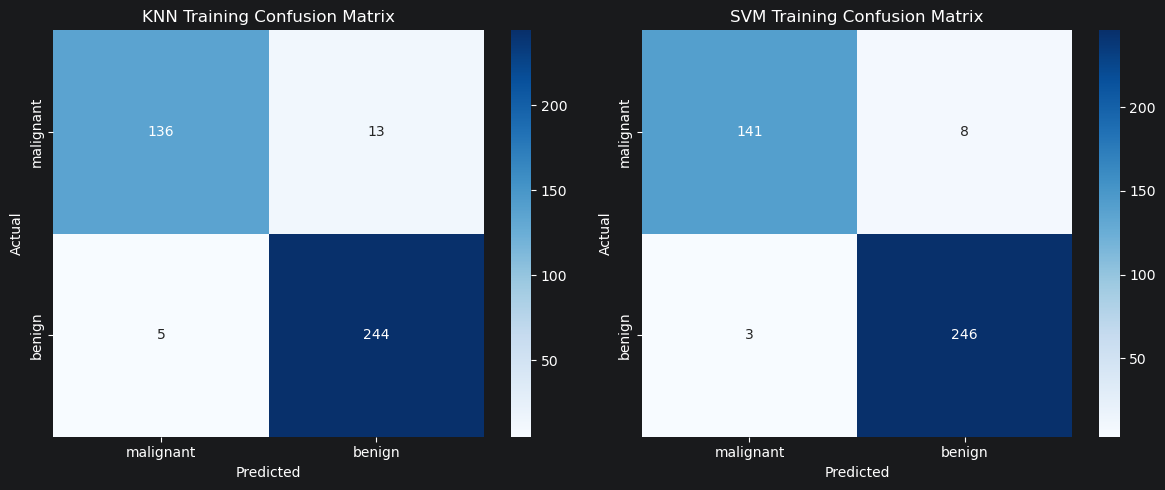

In [18]:
conf_matrix_knn = confusion_matrix(y_train, y_pred_train_knn)
conf_matrix_svm = confusion_matrix(y_train, y_pred_train_svm)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_matrix_knn, annot=True, cmap="Blues", fmt="d", ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title("KNN Training Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_svm, annot=True, cmap="Blues", fmt="d", ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title("SVM Training Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

<p>Ideally the accuracy of a model would be almost the same on the training and testing datasets.</p>
<p>It would be unusual for the accuracy to be higher on the test set and this might occur due to chance or some sort of data leakage. For example, here we have normalized all of the data rather than fitting <code>StandardScaler</code> to the training data and only the applying it to the train and test sets separately. We'll revisit this and other pitfalls in another lab.</p>
<p>When the accuracy is substantially higher on the training data than on the testing data, the model is likely memorizing details in the training data that don't generalize to the unseen data - the model is overfitting to the training data.</p>
<table style="border-collapse: collapse; border: 1px solid; text-align: center;">
    <thead>
    <tr>
        <th style="border: 1px solid; text-align: left;">Model</th>
        <th style="border: 1px solid; text-align: left;">Phase</th>
        <th style="border: 1px solid; text-align: left;">Accuracy</th>
    </tr>
    </thead>
    <tbody>
    <tr>
        <td style="border: 1px solid; text-align: left;">KNN</td>
        <td style="border: 1px solid; text-align: left;">Train</td>
        <td style="border: 1px solid; text-align: left;">95.5%</td>
    </tr>
    <tr>
        <td style="border: 1px solid; text-align: left;">KNN</td>
        <td style="border: 1px solid; text-align: left;">Test</td>
        <td style="border: 1px solid; text-align: left;">93.6%</td>
    </tr>
    <tr>
        <td style="border: 1px solid; text-align: left;">SVM</td>
        <td style="border: 1px solid; text-align: left;">Train</td>
        <td style="border: 1px solid; text-align: left;">97.2%</td>
    </tr>
    <tr>
        <td style="border: 1px solid; text-align: left;">SVM</td>
        <td style="border: 1px solid; text-align: left;">Test</td>
        <td style="border: 1px solid; text-align: left;">97.1%</td>
    </tr>
    </tbody>
</table>
<p>For the SVM model, the training and testing accuracies are essentially the same at about 97%. This is ideal - the SVM model is likely not overfit. For the KNN model, however, the training accuracy is about 2% higher that the test accuracy, indicating there might be some overfitting.</p>
<p>In summary, the SVM model is both more convincing and has a higher accuracy than the KNN model. Remember, we aren't trying to tune these models; we are just comparing their performance with a fixed set of hyperparameters.</p>

****
This is the end of the file.
****